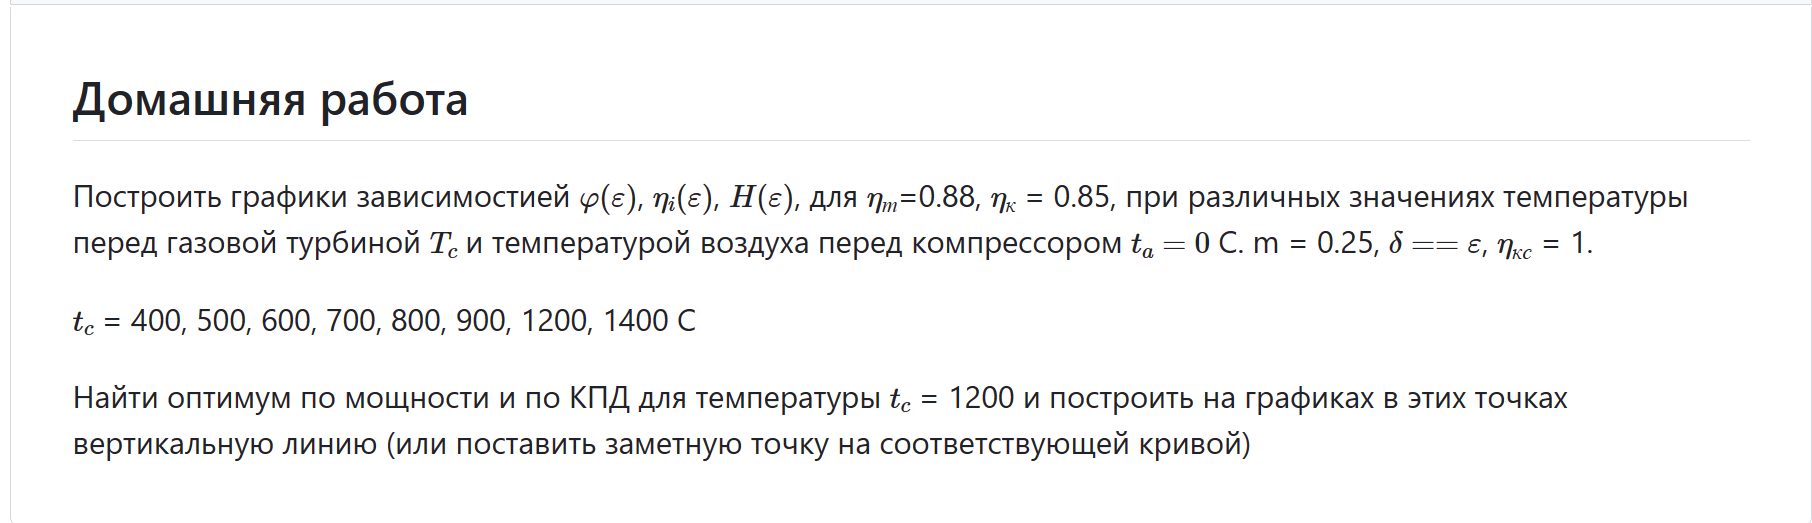

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [14]:
# Исходные данные 
eff_t = 0.88
eff_k = 0.85
eff_kc = 1
t_a = 0
m = 0.25
t_c = np.array([400,500,600,700,800,900,1200,1400])
Cp = 1200

In [15]:
# Промежуточные расчеты
tau = (t_c+273.15)/(t_a+273.15)
E_max = (tau * eff_t * eff_k) ** (1/m)
step = (E_max )/10000

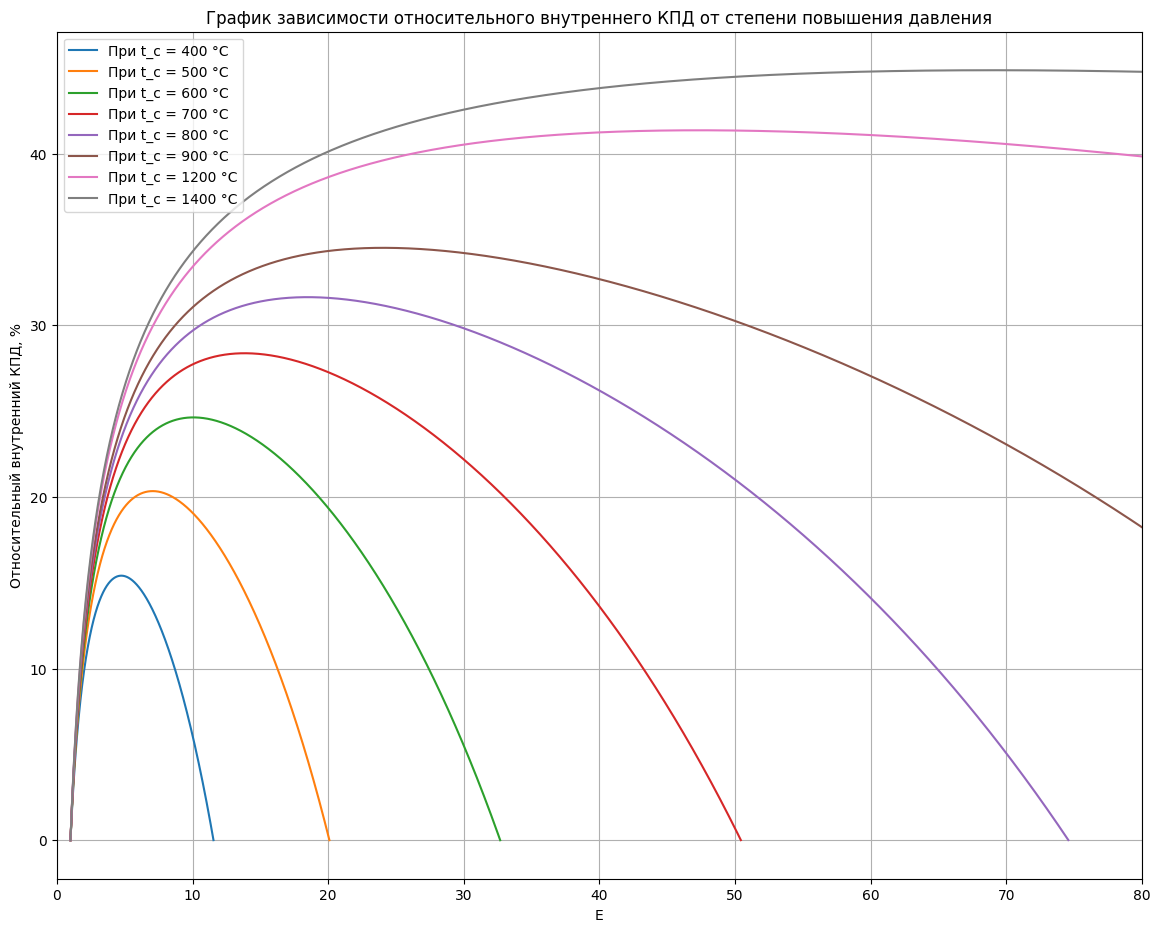

In [16]:
# КПД(E)
fig, graf = plt.subplots(1, 1, figsize=(14, 11))

for i in range(0, 8):
    efficiency = []
    eps = []
    
    for E in np.arange(1, E_max[i], step[i]):
        eps_value = E
        num_1 = tau[i] * eff_t * (1 - E ** (-m))
        num_2 = (E ** m - 1) / eff_k
        denum = tau[i] - 1 - (E ** m - 1) / eff_k
        
        efficiency_value = (num_1 - num_2) / denum
        efficiency.append(efficiency_value * 100)  # Конвертация в проценты
        eps.append(eps_value)
    
    graf.set_title("График зависимости относительного внутреннего КПД от степени повышения давления")
    graf.set_xlabel("E")
    graf.set_ylabel("Относительный внутренний КПД, %")
    graf.set_xlim(0, 80)
    graf.plot(eps, efficiency, label=f"При t_c = {t_c[i]} °C")

graf.grid()
graf.legend()
plt.show()

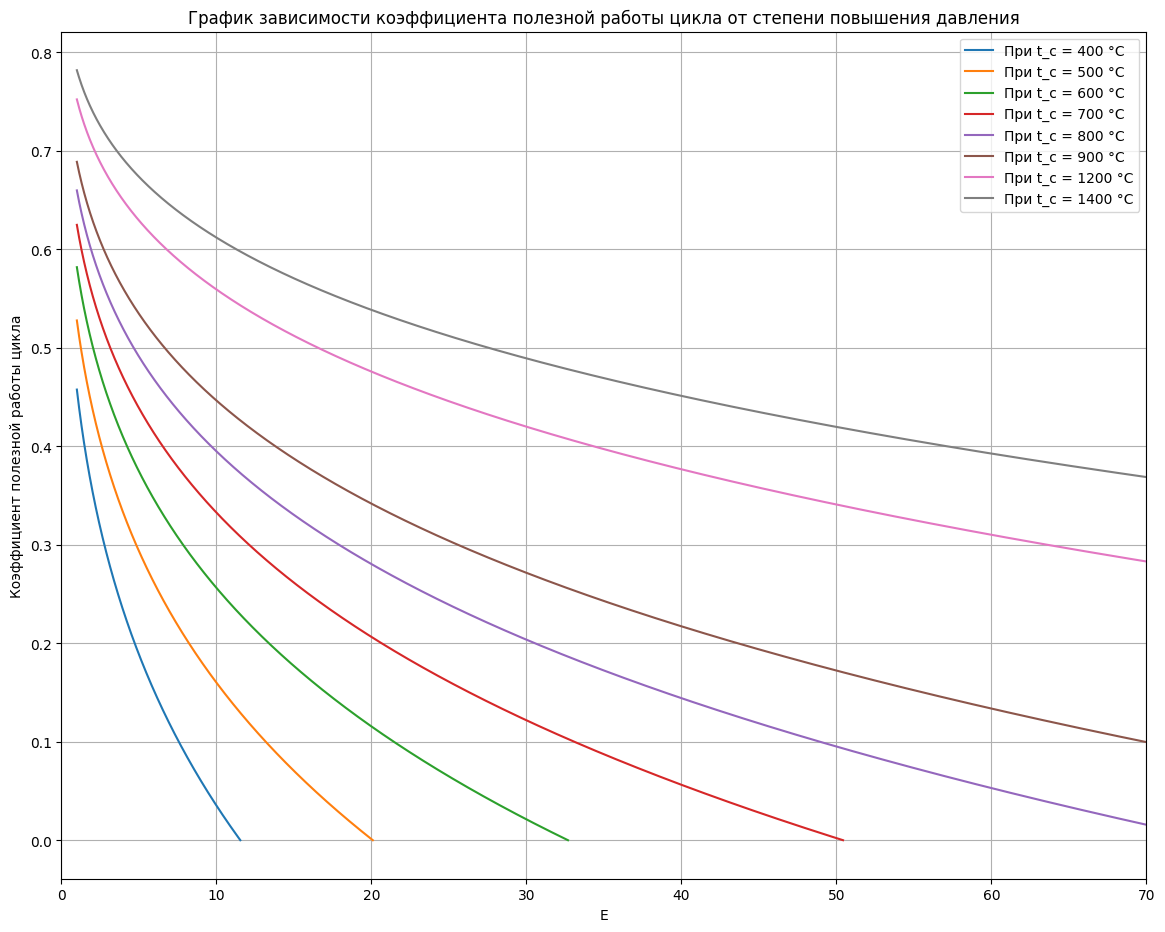

In [17]:
# Фи(E)
fig, graf = plt.subplots(1, 1, figsize=(14, 11))

for i in range(0, 8):
    work_coeff = []
    eps = []
    
    for E in np.arange(1, E_max[i], step[i]):
        eps_value = E
        num = eps_value ** m
        denum = tau[i] * eff_t * eff_k
        
        work_coeff_value = 1 - num / denum
        work_coeff.append(work_coeff_value)
        eps.append(eps_value)
    
    graf.set_title("График зависимости коэффициента полезной работы цикла от степени повышения давления")
    graf.set_xlabel("E")
    graf.set_ylabel("Коэффициент полезной работы цикла")
    graf.set_xlim(0, 70)
    graf.plot(eps, work_coeff, label=f"При t_c = {t_c[i]} °C")

graf.grid()
graf.legend()
plt.show()

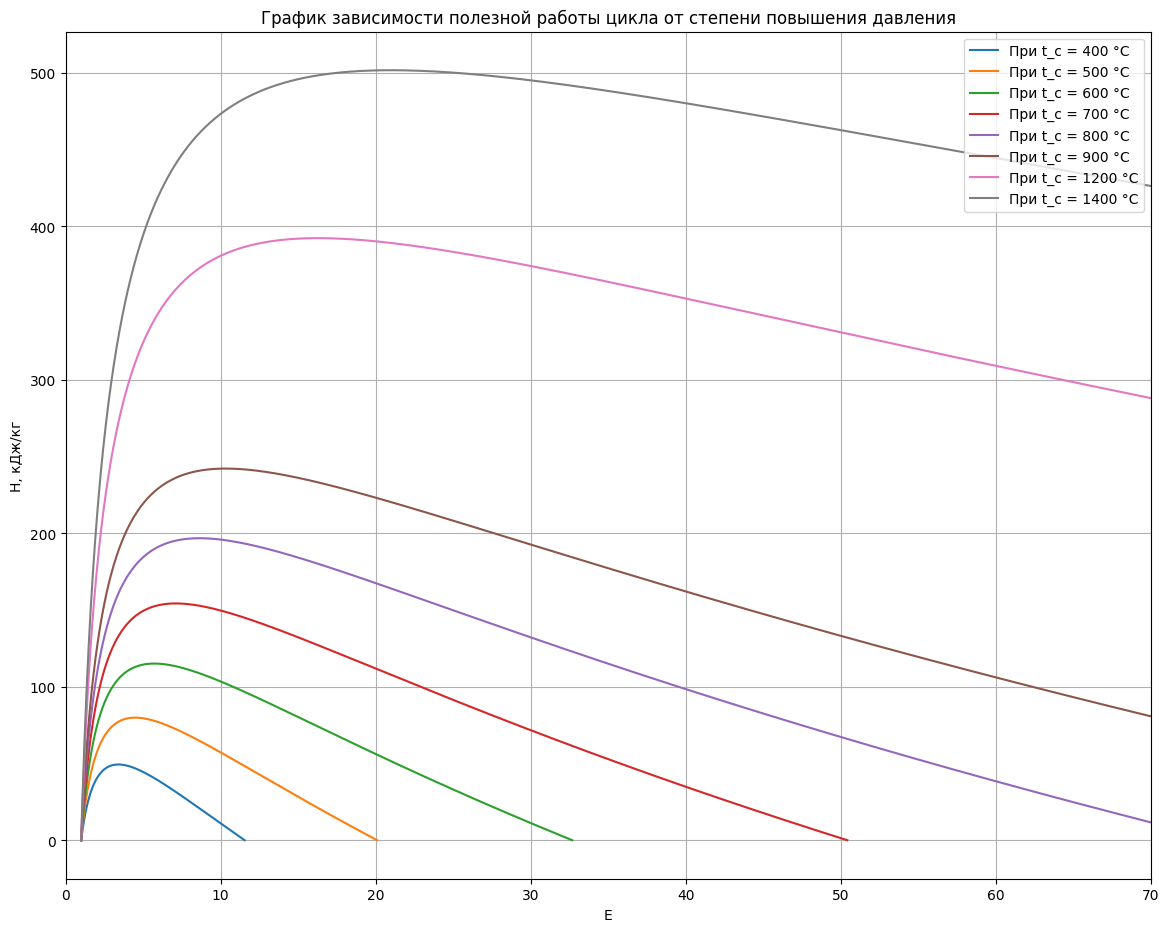

In [18]:
# Н(E) 
fig, graf = plt.subplots(1, 1, figsize=(14, 11))

for i in range(0, 8):
    H = []
    eps = []
    
    for E in np.arange(1, E_max[i], step[i]):
        eps_value = E
        H_t = Cp * (t_c[i] + 273.15) * (1 - E ** (-m)) * eff_t
        H_k = Cp * (t_a + 273.15) * ((E ** m) - 1) / eff_k
        
        H_value = (H_t - H_k) / 1000  # Конвертация в кДж/кг
        H.append(H_value)
        eps.append(eps_value)
    
    graf.set_title("График зависимости полезной работы цикла от степени повышения давления")
    graf.set_xlabel("E")
    graf.set_ylabel("H, кДж/кг")
    graf.set_xlim(0, 70)
    graf.plot(eps, H, label=f"При t_c = {t_c[i]} °C")

graf.grid()
graf.legend(loc="upper right")
plt.show()

[47.32174728] [0.41356921]


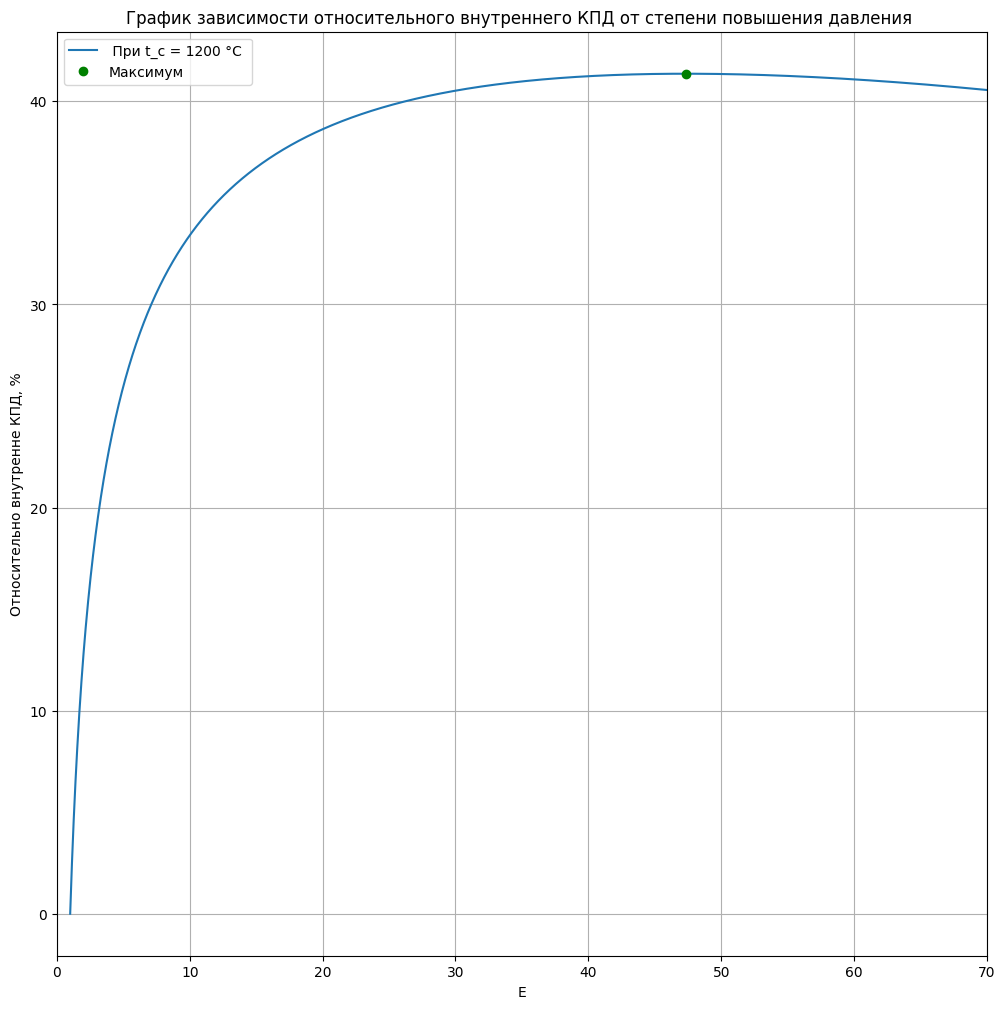

In [19]:
# Определения точки максимума на графике зависимости относительного внутреннего КПД от степени повышения давления
E_max_1200 = E_max[6]
step_1200 = step[6]
tau_1200 = tau[6]
fig, graf = plt.subplots(1, 1, figsize=(12, 12))
efficiency = []
eps = []
efficiency_optimal = 0
def eff_for_opt (E):
    num_1 = tau_1200 * eff_t * (1 - E ** (-m)) 
    num_2 = (E ** m - 1) / eff_k
    denum = tau_1200- 1 - (E ** m - 1) / eff_k
    efficiency_value = (num_1 - num_2) / denum
    return 1 - efficiency_value
for E in np.arange(1,E_max_1200,step_1200):
    eps_value = E 
    num_1 = tau_1200 * eff_t * (1 - E ** (-m)) 
    num_2 = (E ** m - 1) / eff_k
    denum = tau_1200 - 1 - (E ** m - 1) / eff_k
    efficiency_value = (num_1 - num_2) / denum
    efficiency.append(efficiency_value*100)
    eps.append(eps_value)
bounds = ([0.1,1])
optimal = minimize (eff_for_opt,x0 = 0.1, tol = 1e-8)
eps_optimal = optimal.x
efficiency_optimal = 1 - eff_for_opt(eps_optimal)
print(eps_optimal,efficiency_optimal)
graf.set_title("График зависимости относительного внутреннего КПД от степени повышения давления ")
graf.set_xlabel("E")
graf.set_ylabel("Относительно внутренне КПД, %")
graf.set_xlim(0, 70)
graf.plot(eps,efficiency, label = f" При t_c = {t_c[6]} °C ")
graf.plot(eps_optimal,efficiency_optimal *100, 'go' ,label = f"Максимум")
graf.grid()
graf.legend();

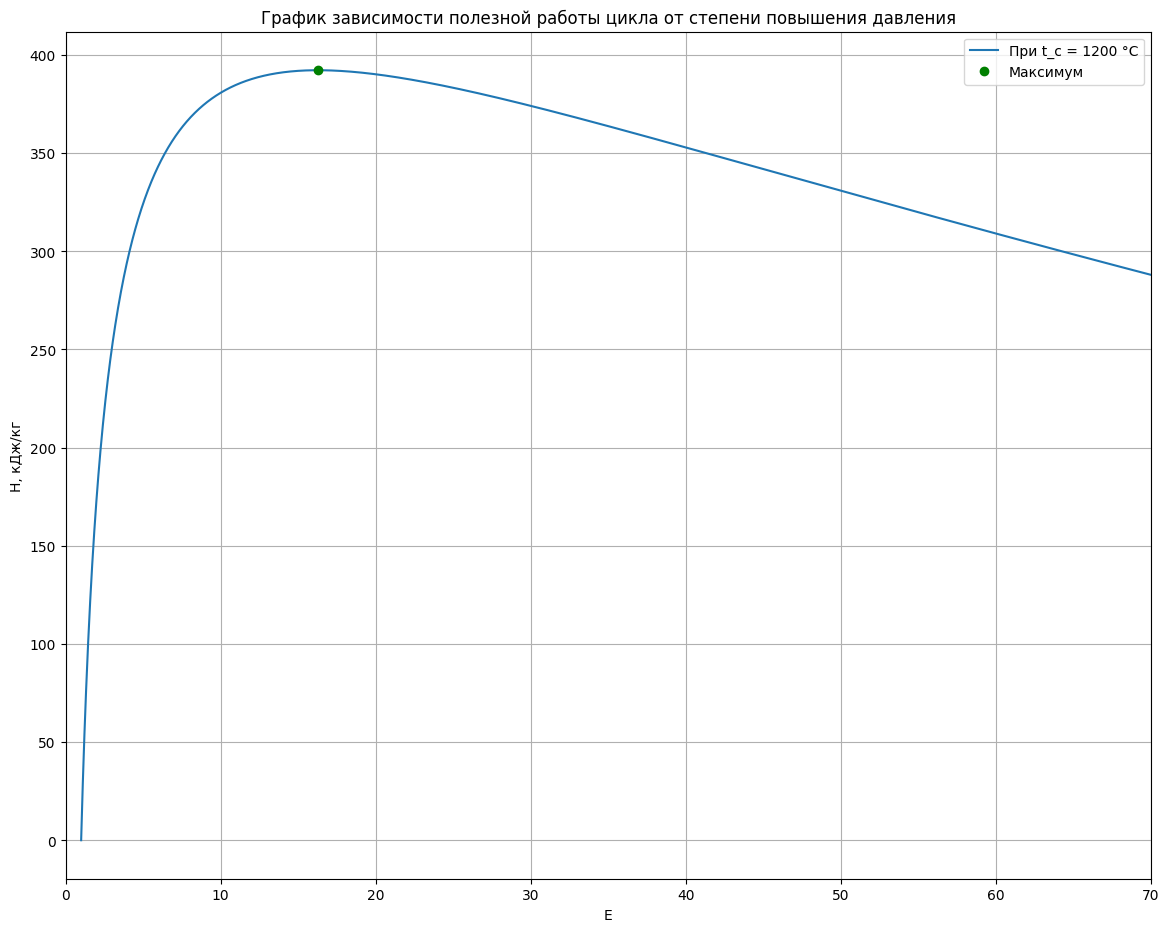

In [20]:
fig, graf = plt.subplots(1, 1, figsize=(14, 11))
H = []
eps = []

for E in np.arange(1, E_max_1200, step_1200):
    eps_value = E 
    H_t = Cp * (t_c[6] + 273.15) * (1 - E ** (-m)) * eff_t
    H_k = Cp * (t_a + 273.15) * ((E ** m) - 1) / eff_k
    H_value = (H_t - H_k) / 1000
    H.append(H_value)
    eps.append(eps_value)

eps_optimal = (tau_1200 * eff_k * eff_t) ** (1/(2 * m))

H_t = Cp * (t_c[6] + 273.15) * (1 - eps_optimal ** (-m)) * eff_t
H_k = Cp * (t_a + 273.15) * ((eps_optimal ** m) - 1) / eff_k
H_max = (H_t - H_k) / 1000

graf.set_title("График зависимости полезной работы цикла от степени повышения давления")
graf.set_xlabel("E")
graf.set_ylabel("H, кДж/кг")
graf.set_xlim(0, 70)
graf.plot(eps, H, label=f"При t_c = {t_c[6]} °C")
graf.plot(eps_optimal, H_max, 'go', label="Максимум")
graf.grid()
graf.legend()
plt.show()